In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,root_mean_squared_error
df=pd.read_csv("C:/Users/ADMIN/Downloads/Boston (1).csv")
df

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NX       506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [3]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NX         0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

<Axes: xlabel='RAD'>

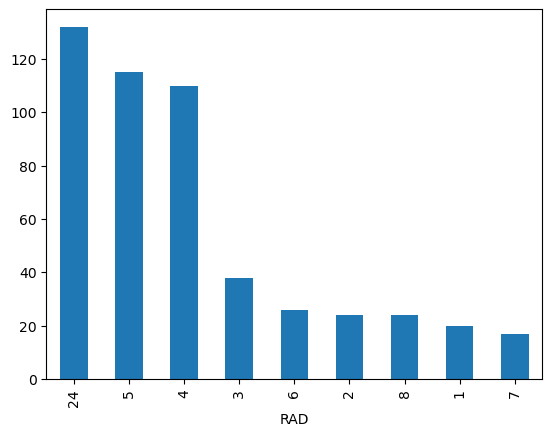

In [4]:
ab=df['RAD'].value_counts()
ab.plot(kind='bar')

In [5]:
ab=df['CHAS'].value_counts()
ab

CHAS
0    471
1     35
Name: count, dtype: int64

<Axes: xlabel='CHAS'>

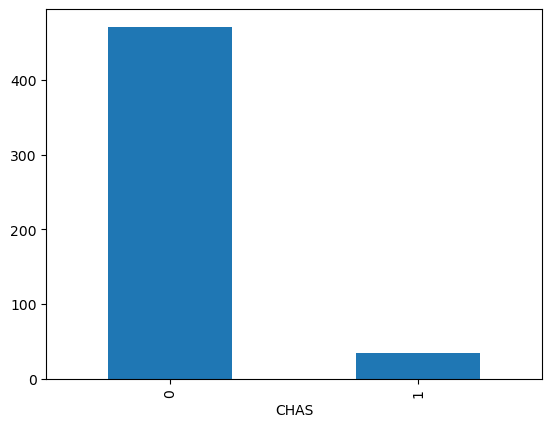

In [6]:
ab.plot(kind='bar')

In [7]:
ab=df['ZN'].value_counts()
ab

ZN
0.0      372
20.0      21
80.0      15
22.0      10
12.5      10
25.0      10
40.0       7
45.0       6
30.0       6
90.0       5
95.0       4
60.0       4
21.0       4
33.0       4
55.0       3
70.0       3
34.0       3
52.5       3
35.0       3
28.0       3
75.0       3
82.5       2
85.0       2
17.5       1
100.0      1
18.0       1
Name: count, dtype: int64

<Axes: xlabel='RAD'>

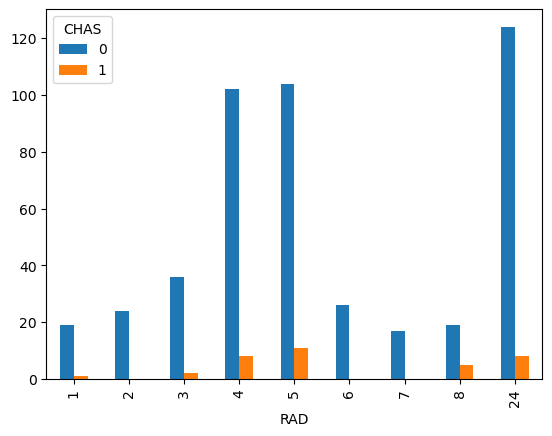

In [8]:
ab=df[['RAD','CHAS']].value_counts().unstack()
ab.plot(kind='bar')

<Axes: >

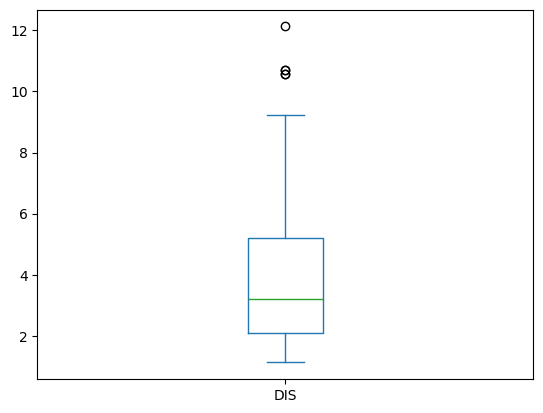

In [9]:
df['DIS'].plot(kind='box')

<Axes: >

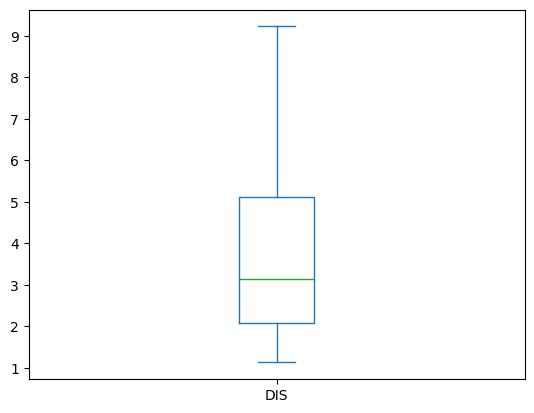

In [10]:
Q1=df['DIS'].quantile(0.25)
Q3=df['DIS'].quantile(0.75)
iqr=Q3-Q1 
lower_bound=Q1-1.5*iqr 
upper_bound=Q3+1.5*iqr
df_no_outliers=df[(df['DIS'] >= lower_bound) & (df['DIS'] <= upper_bound)]
df_no_outliers['DIS'].plot(kind='box')

In [11]:
y=df['MEDV']
x=df.drop('MEDV',axis=1)

In [12]:
x

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48


In [13]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: MEDV, Length: 506, dtype: float64

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=5)

In [15]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((379, 13), (127, 13), (379,), (127,))

In [16]:
lr=LinearRegression()
model=lr.fit(x_train,y_train)

In [17]:
y_pred=model.predict(x_test)
df=pd.DataFrame({'y_test':y_test,'y_pred':y_pred})
df

,y_test,y_pred
226,37.6,37.657162
292,27.9,32.101821
90,22.6,27.008057
373,13.8,6.213310
273,35.2,35.485990
...,...,...
334,20.7,21.923261
331,17.1,19.918342
53,23.4,24.187984
101,26.5,25.648522


In [18]:
print(mean_squared_error(y_test,y_pred))

24.27460831168779


In [19]:
print(root_mean_squared_error(y_test,y_pred))

4.92692686283121


In [20]:
print(r2_score(y_test,y_pred))

0.7059096071098059


In [21]:
y_pred=model.predict(x_train)
df=pd.DataFrame({'y_train':y_train,'y_pred':y_pred})
df

,y_train,y_pred
218,21.5,24.424326
117,19.2,23.515334
195,50.0,41.218485
162,50.0,40.007891
219,23.0,29.211039
...,...,...
486,19.1,19.949126
189,34.9,34.689212
495,23.1,17.349945
206,24.4,23.607811


In [22]:
print("mean_squared_error:",mean_squared_error(y_train,y_pred))

mean_squared_error: 21.514174022233707


In [27]:
print("root_mean_squared_error:",root_mean_squared_error(y_train,y_pred))

root_mean_squared_error: 4.638337420049743


In [28]:
print("r2_score:",r2_score(y_train,y_pred))

r2_score: 0.7468034208269783


In [25]:
df

,y_train,y_pred
218,21.5,24.424326
117,19.2,23.515334
195,50.0,41.218485
162,50.0,40.007891
219,23.0,29.211039
...,...,...
486,19.1,19.949126
189,34.9,34.689212
495,23.1,17.349945
206,24.4,23.607811


In [26]:
count=df[['y_train','y_pred']].value_counts()
count

y_train  y_pred   
5.0      5.548145     1
23.6     30.477914    1
23.9     24.783318    1
23.8     25.438208    1
         25.298957    1
                     ..
18.9     21.388275    1
         15.433251    1
18.8     20.534357    1
         19.802292    1
50.0     43.746694    1
Name: count, Length: 379, dtype: int64